Affichage des premières lignes du fichier CSV:

    CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

 Nombre de valeurs manquantes dans chaque colonne:

 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

 Affichage des doublons:

 Empty DataFrame
Columns: [CustomerID, Gender, Age, Annual Income (k$), Spending Score (1-100)]
Index: []

 Affichage des colonnes pertinentes:

    Age  Annual Income (k$)  Spending Score (1-100)
0   19                  15                      39
1   21                  15                 

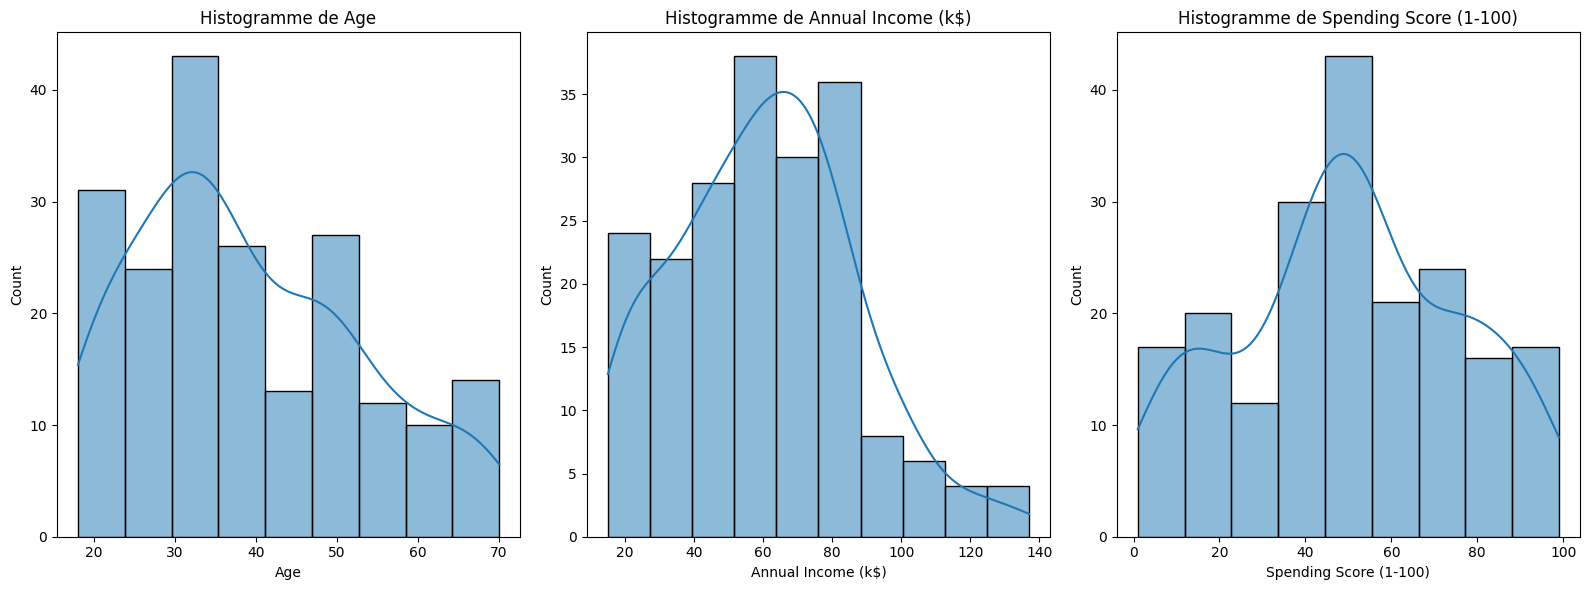

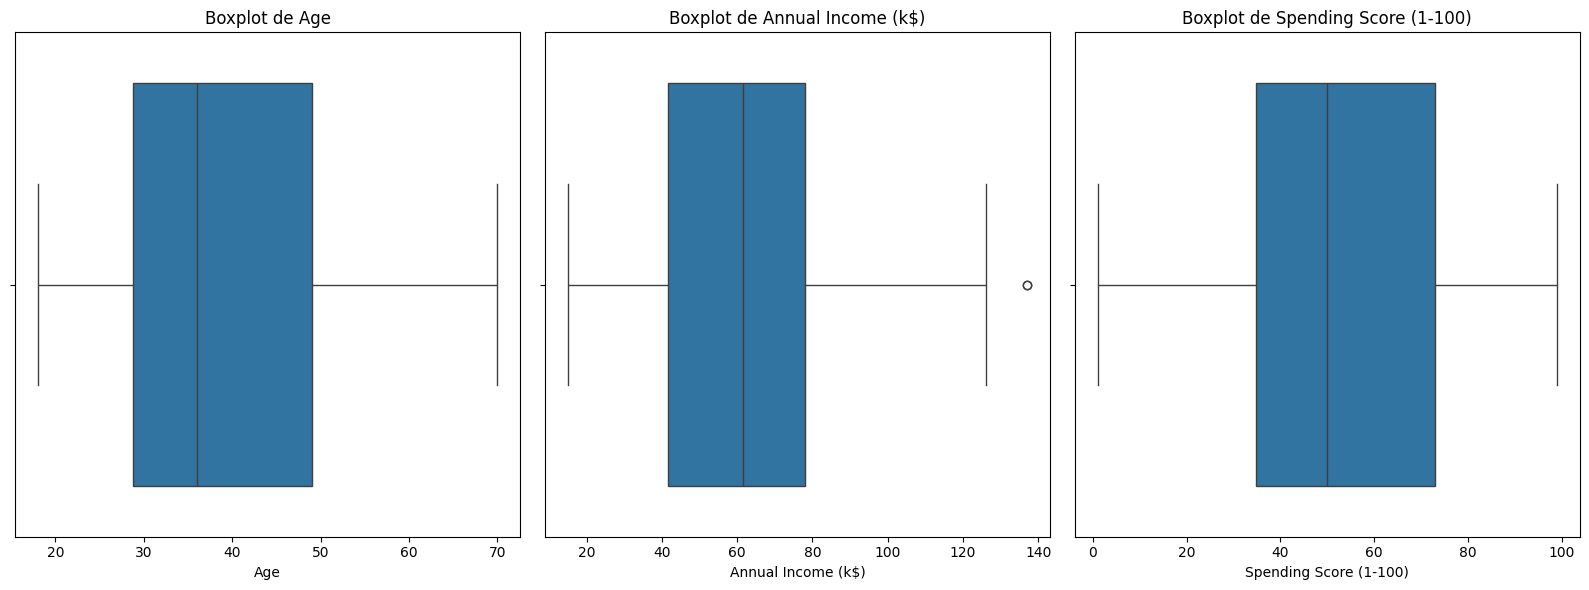

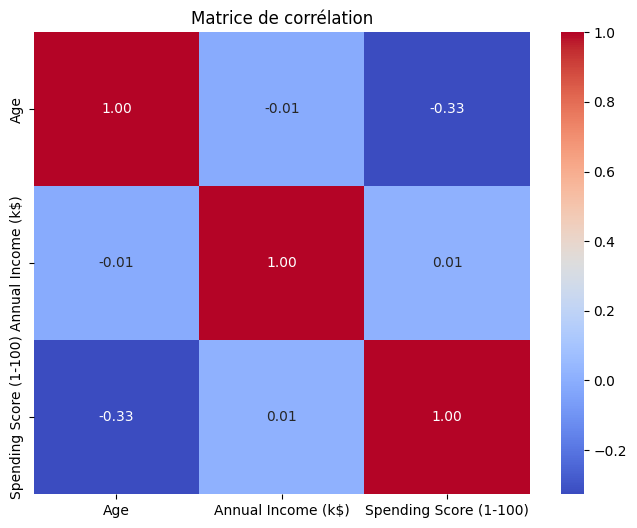

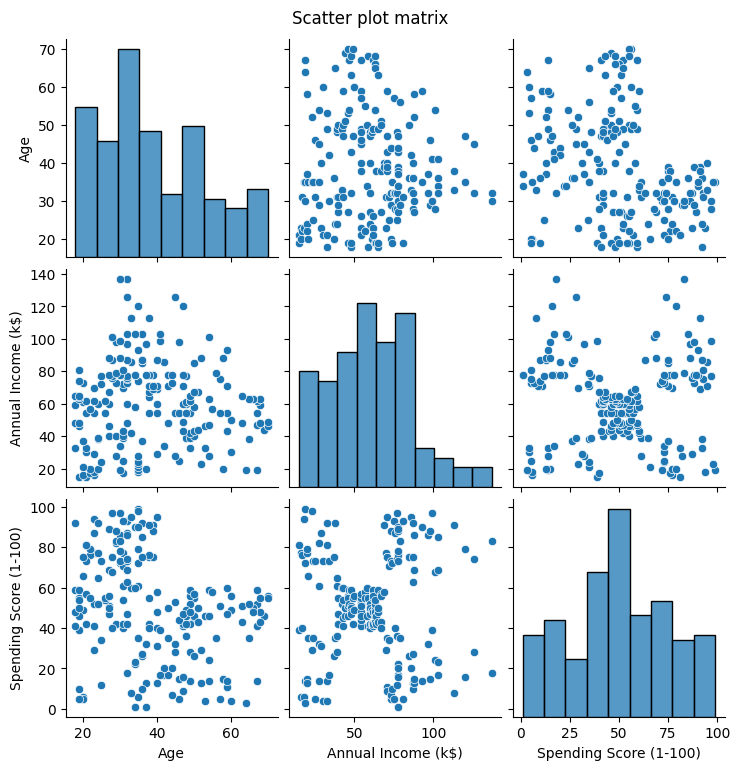


 Données avec la nouvelle colonne Age_Group
     Age     Age_Group
63    54        Adulte
161   29  Adulte Jeune
178   59        Adulte
67    68        Senior
152   44        Adulte


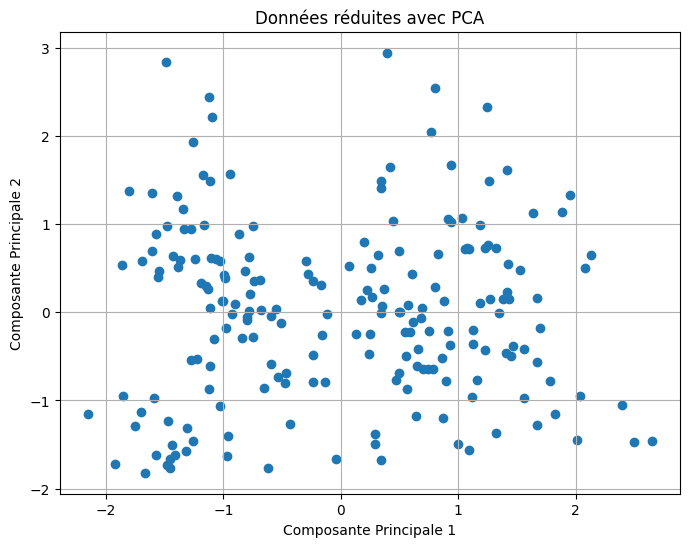

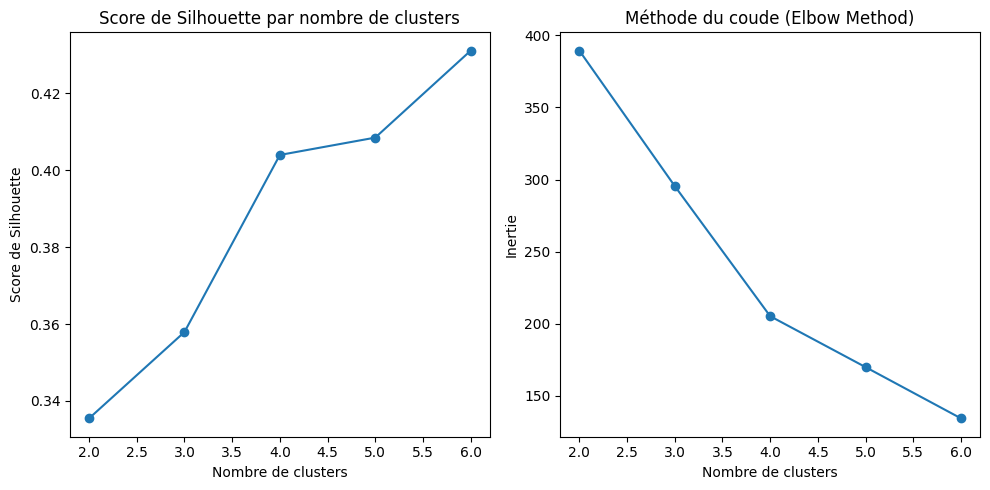

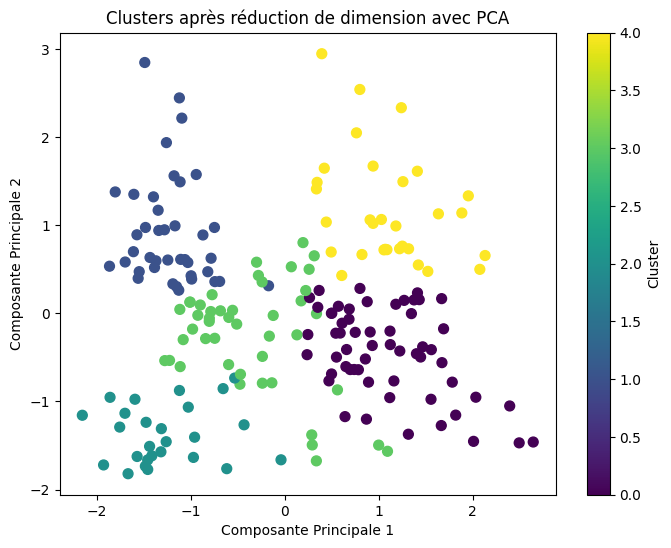

In [ ]:
import pandas as pd 

# Chargement du fichier Mall_Customers.csv 
data_path = "../../data/mall/Mall_Customers.csv"
df = pd.read_csv(data_path)

# Affichage des premières lignes du fichier csv
print("Affichage des premières lignes du fichier CSV:")
print("\n",df.head())



# Nettoyage et pretraitement des données
# Verifier les valeurs manquantes
print("\n Nombre de valeurs manquantes dans chaque colonne:")
print("\n",df.isnull().sum())

#Afficher les doublons
doublons = df[df.duplicated()]

#Afficher les doublons
print("\n Affichage des doublons:")
print("\n", doublons)

# Supprimer les doublons
df.drop_duplicates(inplace=True)

# Selectionner les colonnes pertinentes
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

# Affichage des colonnes pertinentes
print("\n Affichage des colonnes pertinentes:")
print("\n", X.head())


# Standariser les variables quantiatives
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n Affichage des données standardisées:")
print("\n", pd.DataFrame(X_scaled, columns=features).head())

# 3- EDA univariée et multivariée
import matplotlib.pyplot as plt
import seaborn as sns

#Histogramme 
plt.figure(figsize=(16, 6))
for i, col in enumerate(features):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogramme de {col}')
plt.tight_layout()
plt.savefig("../../outputs/clustering/graph/histogrammes.png")
plt.show()

# Boxplot
plt.figure(figsize=(16, 6))
for i, col in enumerate(features):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.savefig("../../outputs/clustering/graph/boxplots.png")
plt.show()

#Matrice de correlation
plt.figure(figsize=(8, 6))
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de corrélation')
plt.savefig("../../outputs/clustering/graph/matrice_correlation.png")
plt.show()

# Scatter plot matrix
sns.pairplot(df[features])
plt.suptitle("Scatter plot matrix", y=1.02)
plt.savefig("../../outputs/clustering/graph/scatter_plot_matrix.png")
plt.show()


# 4- Feature Engineering / Sélection
# Ajouter une variable categorielle pour l'age 
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 25, 40, 60, 100],
                    labels=['Jeune', 'Adulte Jeune', 'Adulte', 'Senior'])

#Affichage des nouvelles données
print("\n Données avec la nouvelle colonne Age_Group")
print(df[['Age', 'Age_Group']].sample(5))

# 5- Reduction de dimension
from sklearn.decomposition import PCA

#Reduction à 2 dimensions
pca = PCA(n_components=2)
X_pca = pca .fit_transform(X_scaled)

#Visualisation des données réduites
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.title('Données réduites avec PCA')
plt.xlabel('Composante Principale 1')
plt.ylabel('Composante Principale 2')
plt.grid(True)
plt.savefig("../../outputs/clustering/graph/pca_reduction.png")
plt.show()

# 6- Clustering avec KMeans
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []
inertias = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_

    silhouette_avg = silhouette_score(X_scaled, labels)
    silhouette_scores.append(silhouette_avg)
    inertias.append(kmeans.inertia_)

#Graphique Silhouette
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(range(2, 7), silhouette_scores, marker='o')
plt.title('Score de Silhouette par nombre de clusters')
plt.xlabel('Nombre de clusters')
plt.ylabel('Score de Silhouette')

# Graphique Elbow
plt.subplot(1, 2, 2)
plt.plot(range(2, 7), inertias, marker='o')
plt.title('Méthode du coude (Elbow Method)')
plt.xlabel('Nombre de clusters')
plt.ylabel('Inertie')
plt.tight_layout()
plt.savefig("../../outputs/clustering/graph/silhouette_elbow.png")
plt.show()

# 7- Interpretation des Clusters
best_k = 5
kmeans = KMeans(n_clusters=best_k, random_state=42)
kmeans.fit(X_scaled)
labels = kmeans.labels_

#Sauvegarde le modele
import joblib
joblib.dump(kmeans, "../../models/clustering/kmeans_model.pkl")

# Ajouter cluster au dataFrame
df['Cluster'] = labels

# Visualisation des clusters avec PCA
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50)
plt.title('Clusters après réduction de dimension avec PCA')
plt.xlabel('Composante Principale 1')
plt.ylabel('Composante Principale 2')
plt.colorbar(label='Cluster')
plt.savefig("../../outputs/clustering/graph/clusters_pca.png")
plt.show()

# Inverser la standardisation pour interpréter les centroides
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=features)
centroids_df['Cluster'] = range(best_k)


# Exporter les centroides
centroids_df.to_csv("../../outputs/clustering/centroids.csv", index=False)

# Affichage des centroides
print("\n Centroides des clusters:")
print("\n", centroids_df)

